#Instacart Market Basket Dataset

Instacart is a grocery delivery platform that allows customers to order groceries online and have them delivered, similar to services like Uber Eats or DoorDash. This dataset captures detailed information about customer shopping behavior, including items purchased, order sequences, and product categories. It is useful for analyzing purchase patterns, popular products, and cart-building behaviors.

The dataset contains individual-level entries with details such as product name, category, order sequence, quantity, and add-to-cart priority, enabling insights into which products are added first and overall shopping trends.

In [121]:
# Importing libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
from google.colab import files
uploaded = files.upload()
#The data is available at https://www.kaggle.com/c/instacart-market-basket-analysis/overview

#Importing the datasets
orders=pd.read_csv('instacart_orders.csv',sep=';')
products=pd.read_csv('products.csv',sep=';')
order_products=pd.read_csv('order_products.csv',sep=';')
departments=pd.read_csv('departments.csv',sep=';')
aisles=pd.read_csv('aisles.csv',sep=';')

Saving instacart_orders.csv to instacart_orders (1).csv
Saving aisles.csv to aisles (1).csv
Saving departments.csv to departments (1).csv
Saving order_products.csv to order_products (1).csv
Saving products.csv to products (1).csv


# Dataset overview and basic statistics

## Datasets Preview

In [123]:
orders.head()
#first 5 rows

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [124]:
products.head()
#first 5 rows

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [125]:
order_products.head()
#first 5 rows

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [126]:
departments.head()
#first 5 rows

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [127]:
aisles.head()
#first 5 rows

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [128]:
print(f"The shape of orders table: {orders.shape}")
print(f"The shape of order_products table: {order_products.shape}")
print(f"The shape of products table: {products.shape}")
print(f"The shape of departments table: {departments.shape}")
print(f"The shape of aisles table: {aisles.shape}")
#shape of datasets (rows,columns)

The shape of orders table: (478967, 6)
The shape of order_products table: (4545007, 4)
The shape of products table: (49694, 4)
The shape of departments table: (21, 2)
The shape of aisles table: (134, 2)


Among all tables, the order_products table has the highest number of observations, comprising 4,545,007 rows and 4 variables. The orders table follows with 478,967 rows and 6 variables, whereas the products table contains 49,694 rows and 4 variables. The departments and aisles tables are relatively small, with 21 and 134 observations respectively, each including 2 variables.

In [129]:
print("Orders info:\n")
orders.info()
print("\n######################################################\n")
print("Order_products info:\n")
order_products.info(show_counts=True )
print("\n######################################################\n")
print("Products info:\n")
products.info()
print("\n######################################################\n")
print("Departments info:\n")
departments.info()
print("\n######################################################\n")
print("Aisles info:\n")
aisles.info()
#the columns and their data types in each datasets

Orders info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

######################################################

Order_products info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2

All data types are correct, we don't need to change any of them.

## Finding and Removing Null Values

In [130]:
orders.isnull().sum()
#Do we have null values or not in orders dataset

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,28819


We have null values in day_since_prior_order column.

In [131]:
orders.isnull().mean()*100
#checking the ratio of missing data

,0
order_id,0.000000
user_id,0.000000
order_number,0.000000
order_dow,0.000000
order_hour_of_day,0.000000
days_since_prior_order,6.016907


The percentage of missing values is minimal.

In [132]:
orders.dropna()
#rows containing null values were removed

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


Since only 6.02% of the data was missing, removing these entries is unlikely to have a major impact on the dataset or the analysis.

In [133]:
departments.isnull().sum()
#Do we have null values or not in departments dataset

,0
department_id,0
department,0


We don't have null values, that's why we don't need to drop or fill any  column.

In [134]:
aisles.isnull().sum()
#Do we have null values or not in aisles dataset

,0
aisle_id,0
aisle,0


We don't have null values, that's why we don't need to drop or fill any  column.

In [135]:
order_products.isnull().sum()
#Do we have null values or not in order_products dataset

,0
order_id,0
product_id,0
add_to_cart_order,836
reordered,0


We have null values in add_to_cart_order column.

In [136]:
order_products.isnull().mean()*100
#checking the ratio of missing data

,0
order_id,0.000000
product_id,0.000000
add_to_cart_order,0.018394
reordered,0.000000


The percentage of missing values is very minimal.

In [137]:
order_products.dropna()
#rows containing null values were removed

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1
...,...,...,...,...
4545002,577211,15290,12.0,1
4545003,1219554,21914,9.0,0
4545004,692640,47766,4.0,1
4545005,319435,691,8.0,1


Although the dataset is very large (~4 million rows), only 836 rows show missing values for non-first orders. This is due to prior removal of NaN values during data cleaning.

In [138]:
products.isnull().sum()
#Do we have null values or not in products dataset

,0
product_id,0
product_name,1258
aisle_id,0
department_id,0


We have null values in product_name column.

In [139]:
products.isnull().mean()*100
#checking the ratio of missing data

,0
product_id,0.000000
product_name,2.531493
aisle_id,0.000000
department_id,0.000000


The percentage of missing values is minimal.

In [140]:
products.dropna()
#rows containing null values were removed

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


The proportion of missing data was only 2.53%, this operation is unlikely to significantly affect the dataset or the analysis.

In [141]:
orders.describe().T
#display summary statistics

,count,mean,std,min,25%,50%,75%,max
order_id,478967.0,1.709947e+06,986948.000707,4.0,856468.5,1709522.0,2562990.0,3421079.0
user_id,478967.0,1.029665e+05,59525.328991,2.0,51414.0,102633.0,154419.0,206209.0
order_number,478967.0,1.715781e+01,17.704688,1.0,5.0,11.0,23.0,100.0
order_dow,478967.0,2.775058e+00,2.045869,0.0,1.0,3.0,5.0,6.0
order_hour_of_day,478967.0,1.344668e+01,4.224986,0.0,10.0,13.0,16.0,23.0
days_since_prior_order,450148.0,1.110175e+01,9.189975,0.0,4.0,7.0,15.0,30.0


**Count**

The count only returns the number of non-null values.The count value is the same for all columns except for days_since_prior_order. The reason is that this column contains null values.

**Mean**

The mean shows the average value of each column.

**Std**

The std represents the standard deviation.

**Min**

The min returns the minimum value.

**Max**

The max returns the maximum value.

**25%**

*order_number* - 25% of users have ordered 5 or fewer orders.

*order_dow* - 25% of users make purchases on the first day of the week.

*order_hour_of_day* - 25% of users make orders by 10:00 a.m.

*days_since_prior_order* - 25% of users wait up to 4 days before placing their next order.

**50%**

*order_number* - 50% of users have ordered 11 or fewer orders.

*order_dow* - 50% of users make purchases within the first three days of the week.

*order_hour_of_day*  - 50% of users make orders by 1:00 p.m.

*days_since_prior_order* - 50% of users wait up to 7 days before placing their next order.


**75%**

*order_number* - 75% of users have ordered 23 or fewer orders.

*order_dow* - 75% of users make purchases within the first five days of the week.

*order_hour_of_day* - 75% of users make orders by 4:00 p.m.

*days_since_prior_order* - 75% of users wait up to 15 days before placing their next order.

## Finding and Removing Duplicate Values

### `orders` Data Frame

In [142]:
#Checking for duplicated orders
orders_duplicated=orders[orders.duplicated()]
orders_duplicated

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


We have duplicated values. Duplicate values are removed to increase the accuracy and quality of the analysis.

In [143]:
# Removing fully duplicated rows so each order record is counted once.
orders.drop_duplicates(inplace=True)

After removing duplicates, the dataset is clean and ready for accurate analysis.

In [144]:
# Double checking for duplicate rows
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


There are no  duplicated rows.

In [145]:
# Double checking for duplicate order IDs only
orders[orders["order_id"].duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


There are no  duplicated rows, the dataset is clean.

In [146]:
# Checking for all orders placed Wednesday at 2:00 AM
df=orders[orders["order_hour_of_day"]==2]
df=df[df["order_dow"]==3]
df

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


The dataset was filtered to extract orders placed at 2:00 a.m. on Wednesday. First, orders are selected where the order hour is equal to 2, and then among those, only the orders where the day of the week corresponds to Wednesday are kept for further analysis.

### `products` Data Frame

In [147]:
# Checking for fully duplicate rows
products[products.duplicated()]

,product_id,product_name,aisle_id,department_id


No duplicated rows were  founded.

In [148]:
# Checking for just duplicate product IDs
products[products["product_id"].duplicated()]

,product_id,product_name,aisle_id,department_id


No duplicated values were found in product_id.

In [149]:
# Checking for duplicate product names after converting them to lowercase to avoid case-sensitive differences.
products[products["product_name"].str.lower().duplicated()].head()

,product_id,product_name,aisle_id,department_id
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
436,437,NaN,100,21


Duplicated product names were found when compared case-insensitively.

In [150]:
# Checking for duplicate product names that aren't missing
df= products[products["product_name"].notna()]
df[df["product_name"].duplicated()]

,product_id,product_name,aisle_id,department_id


These duplicates were kept because product names may be associated with different product IDs.

### `departments` Data Frame

In [151]:
# Checking for fully duplicate rows
departments[departments.duplicated()]

,department_id,department


No duplicated rows were  founded.

In [152]:
# Checking for just duplicate department_id
departments[departments["department_id"].duplicated()]

,department_id,department


All department ids are unique.

### `aisles` Data Frame

In [153]:
# Checking for fully duplicate rows
aisles[aisles.duplicated()]

,aisle_id,aisle


No duplicated rows were  founded.

In [154]:
# Checking for just duplicate aisles_id
aisles[aisles["aisle_id"].duplicated()]

,aisle_id,aisle


All aisles ids are unique.

### `order_products` Data Frame

In [155]:
# Checking for fullly duplicate rows
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


No duplicated rows were  founded.

In [156]:
# This checks whether the same product appears more than once within the same order.
order_products.duplicated(subset=["order_id", "product_id"]).sum()

np.int64(0)

No product is added more than once within the same order.

## Missing Value Assessment and Treatment

### `products` data frame

In [157]:
products.isnull().sum()

,0
product_id,0
product_name,1258
aisle_id,0
department_id,0


There are 1258 missing values in product_name column.

In [158]:
# Are all of the missing product names associated with aisle ID 100?
df=products[products["product_name"].isna()]
df[df["aisle_id"]==100]
df.head()

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21


In [159]:
df.shape

(1258, 4)

The number of rows where product_name is missing is equal to the number of rows where product_name is missing and aisle_id equals 100.

In [160]:
# Are all of the missing product names associated with department ID 21?
df=products[products["product_name"].isna()]
df[df["department_id"]==21]
df.head()

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21


In [161]:
df.shape

(1258, 4)

All missing product names belong to department ID 21. This is confirmed because the total number of missing product_name values is equal to the number of rows where product_name is missing and department_id is 21.

In [162]:
# What is this aisle and department?
departments[departments["department_id"]==21]

,department_id,department
20,21,missing


In [163]:
aisles[aisles["aisle_id"]==100]

,aisle_id,aisle
99,100,missing


Both aisle and department are "missing".

In [164]:
# Fill missing product names with 'Unknown'
products["product_name"].fillna("Unknown", inplace=True)

Missing product names were filled with "Unknown" to handle null values and ensure data completeness for accurate analysis.

In [165]:
# Double checking for missing values
products.isnull().sum()

,0
product_id,0
product_name,0
aisle_id,0
department_id,0


After rechecking, no missing values were found.

### `orders` Data Frame

In [166]:
orders.isnull().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,28817


There are 28817 missing values in days_since_prior_order column.

In [167]:
# Are there any missing values where it's not a customer's first order?
df=orders[orders["days_since_prior_order"].isna()]
df[df["order_number"]==1].head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN


In [168]:
df.shape

(28817, 6)

All missing values are associated only with customer's first orders. There are no missing values for subsequent orders.

### `order_products` data frame

In [169]:
order_products.isnull().sum()

,0
order_id,0
product_id,0
add_to_cart_order,836
reordered,0


There are 836 missing values in add_to_cart_order column.

In [170]:
# What are the min and max values in this column?
order_products.groupby("order_id")["add_to_cart_order"].agg(["min"]).sort_values("min").head(1)

,min
order_id,
3420972,1.0


In [171]:
order_products.groupby("order_id")["add_to_cart_order"].agg(["max"]).sort_values("max").tail(1)

,max
order_id,
747668,64.0


Users order min 1 and max 64 product.

In [172]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
df=order_products[order_products["add_to_cart_order"].isna()]
df['order_id'].drop_duplicates()

,order_id
737,2449164
9926,1968313
14394,2926893
16418,1717990
30114,1959075
...,...
2437093,9310
2438301,2170451
3275635,2979697
3282194,1625713


All order ids which contain missing values.

In [173]:
# Do all orders with missing values have more than 64 products?
df=order_products[order_products["add_to_cart_order"].isna()]
df=df['order_id'].drop_duplicates()
order_sizes = order_products.groupby("order_id")["product_id"].count()
(order_sizes[df] > 64).all()

np.True_

This indicates that all affected orders include more than 64 products.

In [174]:
# Replace missing values with 999 and convert column to integer type
order_products["add_to_cart_order"] = order_products["add_to_cart_order"].fillna(999).astype("int64")

Missing values were successfully replaced with 999, and the column was converted to integer type to ensure data consistency and proper numerical processing.

# Dataset Analysis

##Verifying that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible

In [175]:
min=orders['order_hour_of_day'].min()
max=orders['order_hour_of_day'].max()
print(f'order hour of day range from {min} to {max}')

order hour of day range from 0 to 23


In [176]:
min=orders['order_dow'].min()
max=orders['order_dow'].max()
print(f'order dow range from {min} to {max}')

order dow range from 0 to 6


The values in order_hour_of_day are within the range of 0–23, and order_dow values are within the range of 0–6, indicating that the data is valid and consistent.

## What time of day do people shop for groceries?

In [177]:
orders["order_hour_of_day"].value_counts().sort_values(ascending=False).head()

,count
order_hour_of_day,
10,40578
11,40032
15,39789
14,39631
13,39007


The highest number of grocery orders is placed at 10:00 AM, making it the peak shopping hour of the day.

## What day of the week do people shop for groceries?

In [178]:
orders["order_dow"].value_counts().sort_values(ascending=False).head()

,count
order_dow,
0,84090
1,82185
2,65833
5,63488
6,62649


People shop for groceries the most on Monday, the first day of the week.

## How long do people wait until placing another order?

In [179]:
orders["days_since_prior_order"].value_counts().sort_values(ascending=False).head(10)

,count
days_since_prior_order,
30.0,51337
7.0,44577
6.0,33930
4.0,31006
3.0,30224
5.0,30096
2.0,27138
8.0,25361
1.0,20179


Overall, many customers wait around 30 days before placing a new order. However, most new orders are placed within about one week.

## Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays?

In [180]:
# Creating dataframes for each situation
wednesday=orders[orders["order_dow"] == 2]
saturday=orders[orders["order_dow"] == 5]

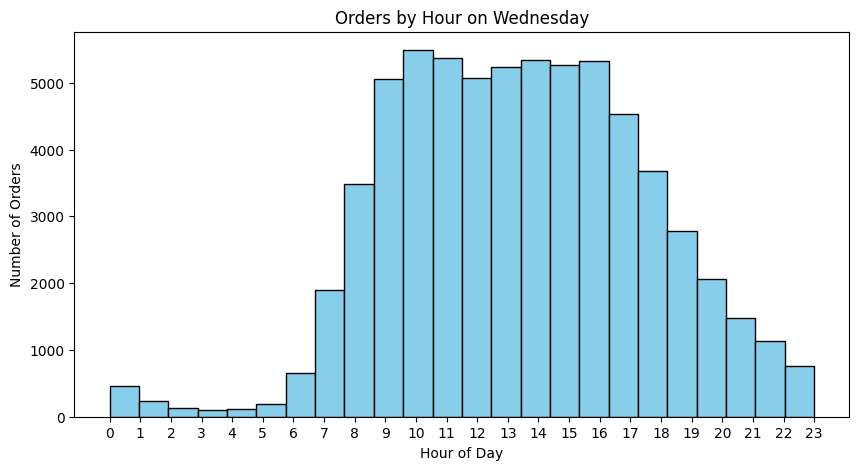

In [181]:
plt.figure(figsize=(10,5))
plt.hist(wednesday["order_hour_of_day"], bins=24, color="skyblue",edgecolor='black')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour on Wednesday")
plt.xticks(range(0,24))
plt.show()

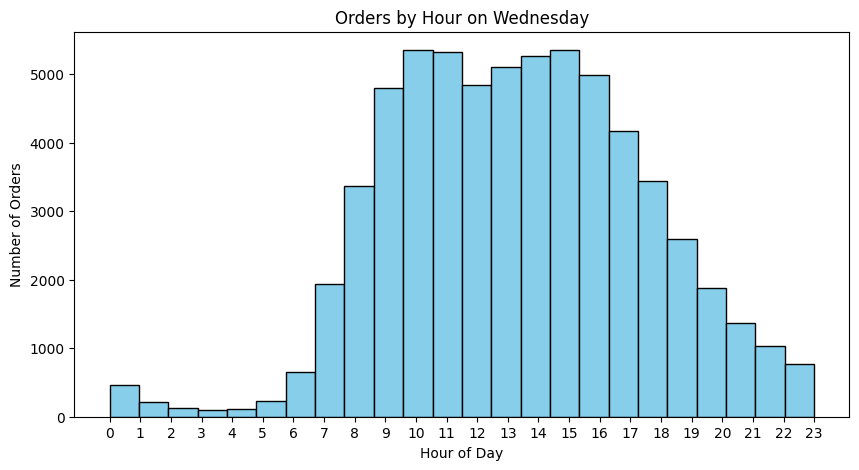

In [182]:
plt.figure(figsize=(10,5))
plt.hist(saturday["order_hour_of_day"], bins=24, color="skyblue",edgecolor='black')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour on Wednesday")
plt.xticks(range(0,24))
plt.show()

On Wednesdays, orders peak in the late morning around 10–11 AM and are more evenly distributed throughout the day, whereas on Saturdays, orders are lower in the morning and peak in the early to mid-afternoon, around 1–4 PM.

## What's the distribution for the number of orders per customer?

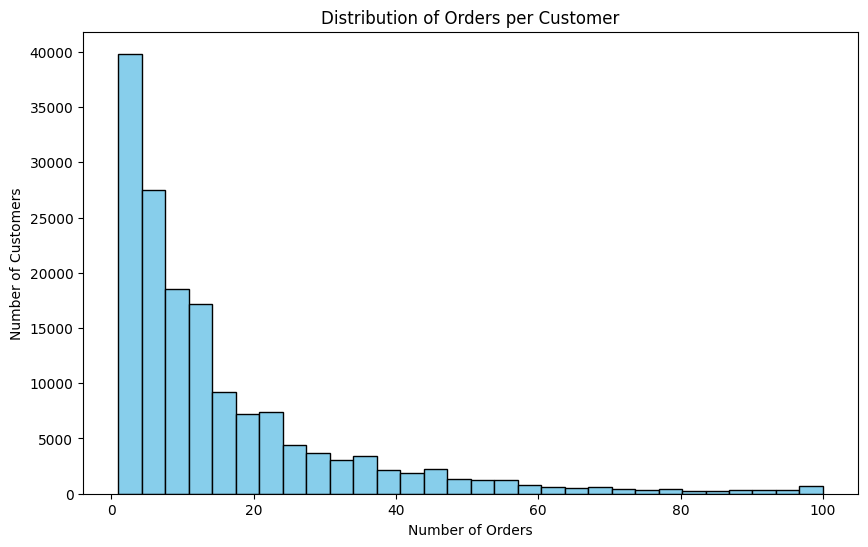

In [183]:
orders_per_user=orders.groupby("user_id")["order_number"].max()
plt.figure(figsize=(10,6))
plt.hist(orders_per_user, bins=30,color='skyblue',edgecolor='black')
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Distribution of Orders per Customer")
plt.show()

The distribution of the number of orders per customer is right-skewed (positively skewed). Most customers placed a small number of orders, while a smaller number of customers placed a much larger number of orders, creating a long tail extending toward 100 orders.

## What are the top 20 popular products?

In [184]:
products_per_order=order_products.groupby(['product_id'])['order_id'].count()
merged_df=pd.merge(products_per_order, products, on='product_id', how='inner')
merged_df.sort_values(by='order_id', ascending=False).head(20)

,product_id,order_id,product_name,aisle_id,department_id
22808,24852,66050,Banana,24,4
12025,13176,53297,Bag of Organic Bananas,24,4
19370,21137,37039,Organic Strawberries,24,4
20077,21903,33971,Organic Baby Spinach,123,4
43271,47209,29773,Organic Hass Avocado,24,4
43788,47766,24689,Organic Avocado,24,4
43663,47626,21495,Large Lemon,24,4
15364,16797,20018,Strawberries,24,4
24047,26209,19690,Limes,24,4
25556,27845,19600,Organic Whole Milk,84,16


Customer preference is mainly concentrated on organic fresh foods, followed by organic vegetables, while dairy products are represented only by organic whole milk.

## How many items do people typically buy in one order? What does the distribution look like?

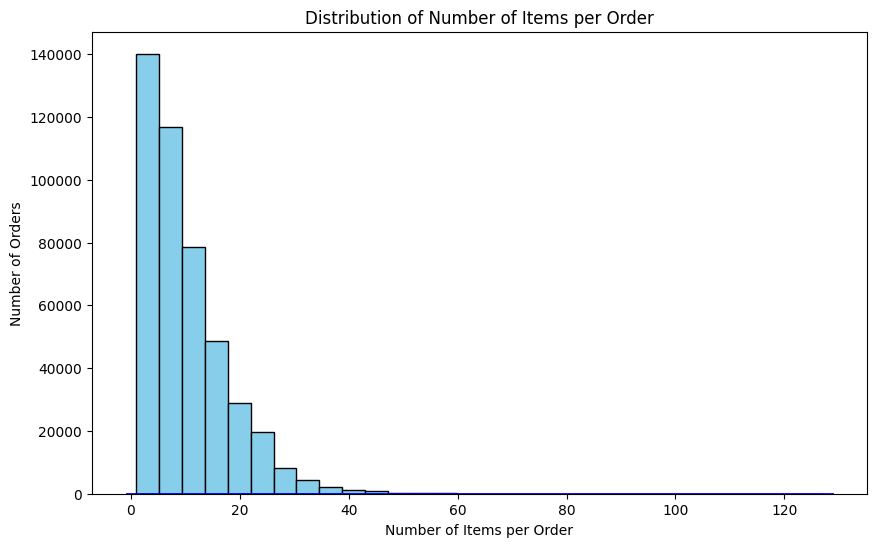

In [185]:
items_per_order=order_products.groupby('order_id')['product_id'].count()
plt.figure(figsize=(10,6))
plt.hist(items_per_order, bins=30,color='skyblue', edgecolor='black')
sns.kdeplot(items_per_order, color="blue", linewidth=2)
plt.xlabel("Number of Items per Order")
plt.ylabel("Number of Orders")
plt.title("Distribution of Number of Items per Order")
plt.show()

The distribution is right-skewed (positively skewed), meaning most orders contain a small number of items, while a small number of orders include a very large number of items. It is unimodal, with a clear peak at low item counts, and it has a long right tail extending toward higher values.

## What are the top 20 items that are reordered most frequently?

In [186]:
reorder_counts=(order_products.groupby('product_id')['reordered'].sum()).sort_values(ascending=False)
merged_df=pd.merge(reorder_counts, products, on='product_id', how='inner')
merged_df.sort_values('reordered',ascending=False).head(20)

,product_id,reordered,product_name,aisle_id,department_id
0,24852,55763,Banana,24,4
1,13176,44450,Bag of Organic Bananas,24,4
2,21137,28639,Organic Strawberries,24,4
3,21903,26233,Organic Baby Spinach,123,4
4,47209,23629,Organic Hass Avocado,24,4
5,47766,18743,Organic Avocado,24,4
6,27845,16251,Organic Whole Milk,84,16
7,47626,15044,Large Lemon,24,4
8,27966,14748,Organic Raspberries,123,4
9,16797,13945,Strawberries,24,4


Most of the listed products belong to the fresh produce category, while a smaller number fall under the dairy category, indicating that customers mainly purchase fresh fruits and vegetables compared to dairy items.

## For each product, what proportion of its orders are reorders?

In [187]:
reorder_prop=(order_products.groupby("product_id")["reordered"].mean().reset_index().rename(columns={"reordered": "reorder_proportion"}))
reorder_prop=reorder_prop.merge(products[["product_id", "product_name"]],on="product_id",how="left")
reorder_prop.sort_values("reorder_proportion", ascending=False).head(20)

,product_id,reorder_proportion,product_name
28108,30644,1.0,Organic French Roast
7340,8054,1.0,Bissli Smokey Wheat Snacks
28114,30650,1.0,Mushroom Lover's Veggie Burgers
41002,44747,1.0,Frozen Organic Blackberries
40998,44743,1.0,Real Zero Cola
32921,35897,1.0,Ham Hock
32861,35834,1.0,Bulgarian Organic Yogurt
2684,2939,1.0,Cheddar Crunchin' Crackers
20357,22209,1.0,Temples Earl Gray Strong Tea
20361,22213,1.0,2% Reduced Fat Chocolate Milk


All products have a reorder proportion of 1.0, meaning every order of these items comes from repeat purchases. This indicates that these products are highly popular among returning customers and are consistently repurchased, reflecting strong customer loyalty and habitual buying behavior.

## For each customer, what proportion of their products ordered are reorders?

In [188]:
user_reorder_prop = (order_products.merge(orders[["order_id", "user_id"]], on="order_id", how="left").groupby("user_id")["reordered"].mean())
user_reorder_prop.describe().round(2)

,reordered
count,149626.00
mean,0.49
std,0.29
min,0.00
25%,0.27
50%,0.50
75%,0.72
max,1.00


On average, nearly half of the products ordered by each customer are reorders, indicating a strong tendency for repeat purchases.

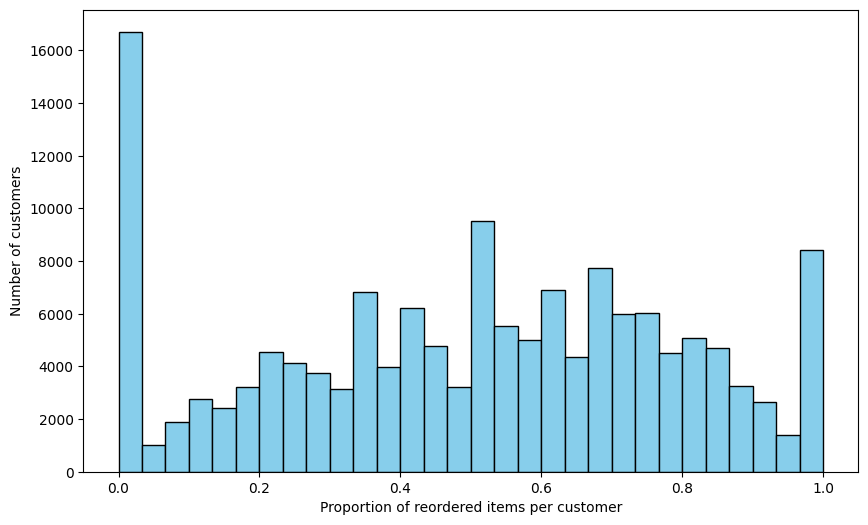

In [189]:
plt.figure(figsize=(10,6))
plt.hist(user_reorder_prop, bins=30,color='skyblue', edgecolor='black')
plt.xlabel("Proportion of reordered items per customer")
plt.ylabel("Number of customers")
plt.show()

Customers vary in their ordering habits, with some mostly buying new items and others frequently reordering the same products.

## What are the top 20 items that people put in their carts first?

In [193]:
first_items=order_products[order_products['add_to_cart_order']==1]
first_items_count=first_items.groupby('product_id')['order_id'].count()
merged_df=pd.merge(first_items_count, products, on='product_id', how='inner')
merged_df.sort_values('order_id',ascending=False).head(20)

,product_id,order_id,product_name,aisle_id,department_id
13414,24852,15562,Banana,24,4
7127,13176,11026,Bag of Organic Bananas,24,4
15028,27845,4363,Organic Whole Milk,84,16
11384,21137,3946,Organic Strawberries,24,4
25439,47209,3390,Organic Hass Avocado,24,4
11786,21903,3336,Organic Baby Spinach,123,4
25732,47766,3044,Organic Avocado,24,4
10622,19660,2336,Spring Water,115,7
9050,16797,2308,Strawberries,24,4
15102,27966,2024,Organic Raspberries,123,4


Top 20 items added first are mostly fresh produce showing a preference for healthy staples.

# Conclusion

Orders were mainly placed during daytime hours, especially between 10:00 and 16:00, while nighttime orders remained low. Most users made repeated purchases, indicating consistent shopping behavior. The analysis showed that certain products consistently appeared among the most frequently ordered items, representing daily essential goods. Users generally created medium-sized shopping baskets, and very large orders were less common. A high reorder rate also indicated that customers frequently repurchased previously selected products.